In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 31.5 MB/s eta 0:00:00


In [6]:
# =========================================================
# [1] 라이브러리 임포트 및 데이터 로드
# =========================================================
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, log_loss, confusion_matrix, make_scorer

file_path = '/content/drive/MyDrive/data_team7.csv'
df = pd.read_csv(file_path)
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

X = df.drop('Attrition', axis=1)
y = df['Attrition']
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# =========================================================
# [2] 기본 데이터 K-Fold Cross Validation
# =========================================================
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    X_train_processed_fold = preprocessor.fit_transform(X_train_fold)
    X_test_processed_fold = preprocessor.transform(X_test_fold)

    pos_weight_fold = (y_train_fold == 0).sum() / (y_train_fold == 1).sum()

    model_xgb_kfold = xgb.XGBClassifier(
        objective='binary:logistic', eval_metric='auc', max_depth=4,
        learning_rate=0.05, n_estimators=300, scale_pos_weight=pos_weight_fold, random_state=42
    )
    model_xgb_kfold.fit(X_train_processed_fold, y_train_fold)

# =========================================================
# [3] 기본 데이터 하이퍼파라미터 튜닝 (Optuna)
# =========================================================
X_train_raw, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_valid_raw, X_test_raw, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

X_train_proc = preprocessor.fit_transform(X_train_raw)
X_valid_proc = preprocessor.transform(X_valid_raw)
X_test_proc = preprocessor.transform(X_test_raw)
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

param_grid = {'max_depth': [3, 4, 5], 'learning_rate': [0.01, 0.05, 0.1], 'n_estimators': [100, 200, 300]}
scoring_metrics = {
    'precision': 'precision', 'recall': 'recall', 'f1': 'f1', 'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision', 'log_loss': make_scorer(log_loss, greater_is_better=False, needs_proba=True)
}

def objective(trial):
    max_depth = trial.suggest_int('max_depth', 3, 5)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.1, log=True)
    n_estimators = trial.suggest_int('n_estimators', 100, 300)

    model = xgb.XGBClassifier(
        objective='binary:logistic', eval_metric='aucpr',
        max_depth=max_depth, learning_rate=learning_rate, n_estimators=n_estimators,
        scale_pos_weight=pos_weight, random_state=42
    )
    model.fit(X_train_proc, y_train)
    y_pred_proba = model.predict_proba(X_valid_proc)[:, 1]
    return average_precision_score(y_valid, y_pred_proba)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

best_xgb_optuna = xgb.XGBClassifier(
    objective='binary:logistic', eval_metric='aucpr',
    **study.best_trial.params, scale_pos_weight=pos_weight, random_state=42
)
best_xgb_optuna.fit(X_train_proc, y_train)

# =========================================================
# [4] 특성 공학(Feature Engineering) 적용 및 Optuna 재튜닝
# =========================================================
def apply_advanced_feature_engineering(df_in):
    df_new = df_in.copy()
    df_new['Total_Satisfaction_Score'] = df_new['EnvironmentSatisfaction'] + df_new['JobSatisfaction'] + df_new['RelationshipSatisfaction'] + df_new['WorkLifeBalance']
    df_new['Income_Per_WorkingYear'] = df_new['MonthlyIncome'] / (df_new['TotalWorkingYears'] + 1)
    df_new['Income_Per_YearAtCompany'] = df_new['MonthlyIncome'] / (df_new['YearsAtCompany'] + 1)
    df_new['Income_Per_Level'] = df_new['MonthlyIncome'] / df_new['JobLevel']
    df_new['Cost_Effectiveness'] = df_new['PercentSalaryHike'] / df_new['PerformanceRating']
    df_new['Burnout_Risk'] = df_new['OverTime'].apply(lambda x: 1 if x == 'Yes' or x == 1 else 0) + (5 - df_new['WorkLifeBalance'])
    df_new['Sat_WLB_Interaction'] = df_new['Total_Satisfaction_Score'] * df_new['WorkLifeBalance']
    df_new['Promotion_Speed_Index'] = df_new['JobLevel'] / (df_new['TotalWorkingYears'] + 1)
    df_new['Stagnation_Index'] = df_new['YearsSinceLastPromotion'] / (df_new['YearsAtCompany'] + 1)
    df_new['Job_Hopping_Index'] = df_new['NumCompaniesWorked'] / (df_new['TotalWorkingYears'] + 1)
    df_new['Loyalty_Ratio'] = np.where(df_new['TotalWorkingYears'] > 0, df_new['YearsAtCompany'] / df_new['TotalWorkingYears'], 0)
    return df_new

df_engineered = apply_advanced_feature_engineering(df)

X_eng = df_engineered.drop('Attrition', axis=1)
y_eng = df_engineered['Attrition']

X_train_eng, X_temp_eng, y_train_eng, y_temp_eng = train_test_split(X_eng, y_eng, test_size=0.3, stratify=y_eng, random_state=42)
X_valid_eng, X_test_eng, y_valid_eng, y_test_eng = train_test_split(X_temp_eng, y_temp_eng, test_size=0.5, stratify=y_temp_eng, random_state=42)

numerical_cols_eng = [col for col in X_eng.columns if col not in categorical_cols]
preprocessor_eng = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_eng),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

X_train_eng_proc = preprocessor_eng.fit_transform(X_train_eng)
X_valid_eng_proc = preprocessor_eng.transform(X_valid_eng)
X_test_eng_proc = preprocessor_eng.transform(X_test_eng)
pos_weight_eng = (y_train_eng == 0).sum() / (y_train_eng == 1).sum()

def objective_eng(trial):
    max_depth = trial.suggest_int('max_depth', 3, 5)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.1, log=True)
    n_estimators = trial.suggest_int('n_estimators', 100, 300)

    model = xgb.XGBClassifier(
        objective='binary:logistic', eval_metric='aucpr',
        max_depth=max_depth, learning_rate=learning_rate, n_estimators=n_estimators,
        scale_pos_weight=pos_weight_eng, random_state=42
    )
    model.fit(X_train_eng_proc, y_train_eng)
    y_pred_proba = model.predict_proba(X_valid_eng_proc)[:, 1]
    return average_precision_score(y_valid_eng, y_pred_proba)

study_eng = optuna.create_study(direction='maximize')
study_eng.optimize(objective_eng, n_trials=100)

# =========================================================
# 추가된 출력 코드
# =========================================================
print("\n=========================================================")
print("[최종 결과] Optuna 튜닝 완료")
print("=========================================================")
print(f"▶ 최고 PR-AUC 점수 : {study_eng.best_value:.4f}")
print(f"▶ 최적 파라미터 :")
for key, value in study_eng.best_trial.params.items():
    print(f"   - {key}: {value}")
print("=========================================================\n")

best_xgb_eng_optuna = xgb.XGBClassifier(
    objective='binary:logistic', eval_metric='aucpr',
    **study_eng.best_trial.params, scale_pos_weight=pos_weight_eng, random_state=42
)
best_xgb_eng_optuna.fit(X_train_eng_proc, y_train_eng)


[최종 결과] Optuna 튜닝 완료
▶ 최고 PR-AUC 점수 : 0.3758
▶ 최적 파라미터 :
   - max_depth: 5
   - learning_rate: 0.0836569563403341
   - n_estimators: 288



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.0836569563403341, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=288, n_jobs=None,
              num_parallel_tree=None, ...)

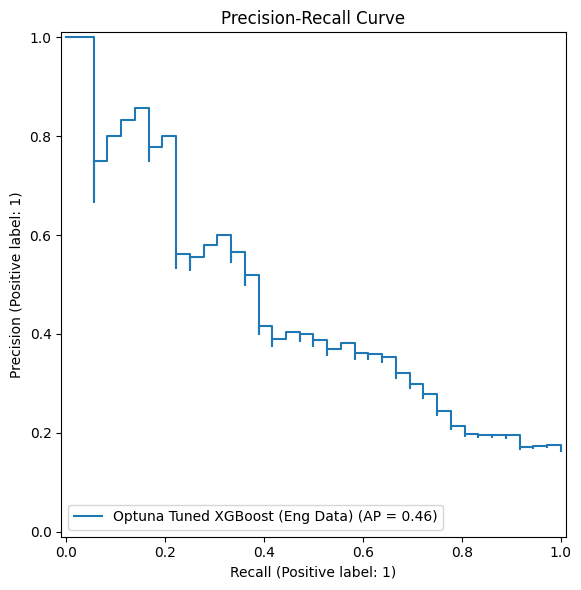

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

y_pred_proba_eng_optuna = best_xgb_eng_optuna.predict_proba(X_test_eng_proc)[:, 1]

plt.figure(figsize=(8, 6))
ax = plt.gca()

PrecisionRecallDisplay.from_predictions(
    y_test_eng,
    y_pred_proba_eng_optuna,
    name="XGBoost",
    ax=ax
)

plt.title('Precision-Recall Curve')
plt.tight_layout()

plt.savefig('XGBoost_Precision-Recall_Curve.pdf')
plt.show()

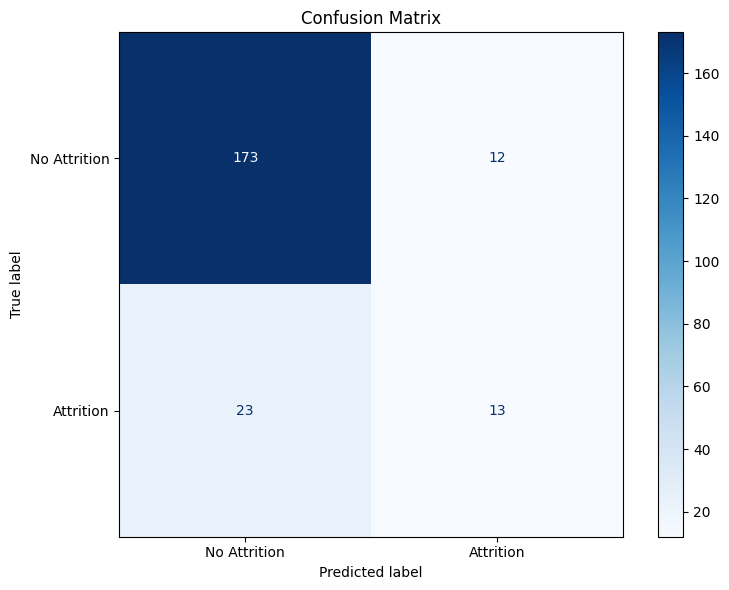

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_eng_optuna = best_xgb_eng_optuna.predict(X_test_eng_proc)

plt.figure(figsize=(8, 6))

ax = plt.gca()

ConfusionMatrixDisplay.from_predictions(
    y_test_eng,
    y_pred_eng_optuna,
    display_labels=['No Attrition', 'Attrition'],
    cmap=plt.cm.Blues,
    ax=ax
)

plt.title('Confusion Matrix')
plt.tight_layout()

plt.savefig('XGBoost_Confusion_Matrix.pdf')
plt.show()

/tmp/ipykernel_629/1052209236.py:68: UserWarning: Glyph 127381 (\N{SQUARED NEW}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_629/1052209236.py:69: UserWarning: Glyph 127381 (\N{SQUARED NEW}) missing from font(s) DejaVu Sans.
  plt.savefig('XGBoost_Feature_Importance_Top20.pdf', dpi=150, bbox_inches='tight')
/tmp/ipykernel_629/1052209236.py:69: UserWarning: Glyph 127381 (\N{SQUARED NEW}) missing from font(s) DejaVu Sans.
  plt.savefig('XGBoost_Feature_Importance_Top20.pdf', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127381 (\N{SQUARED NEW}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


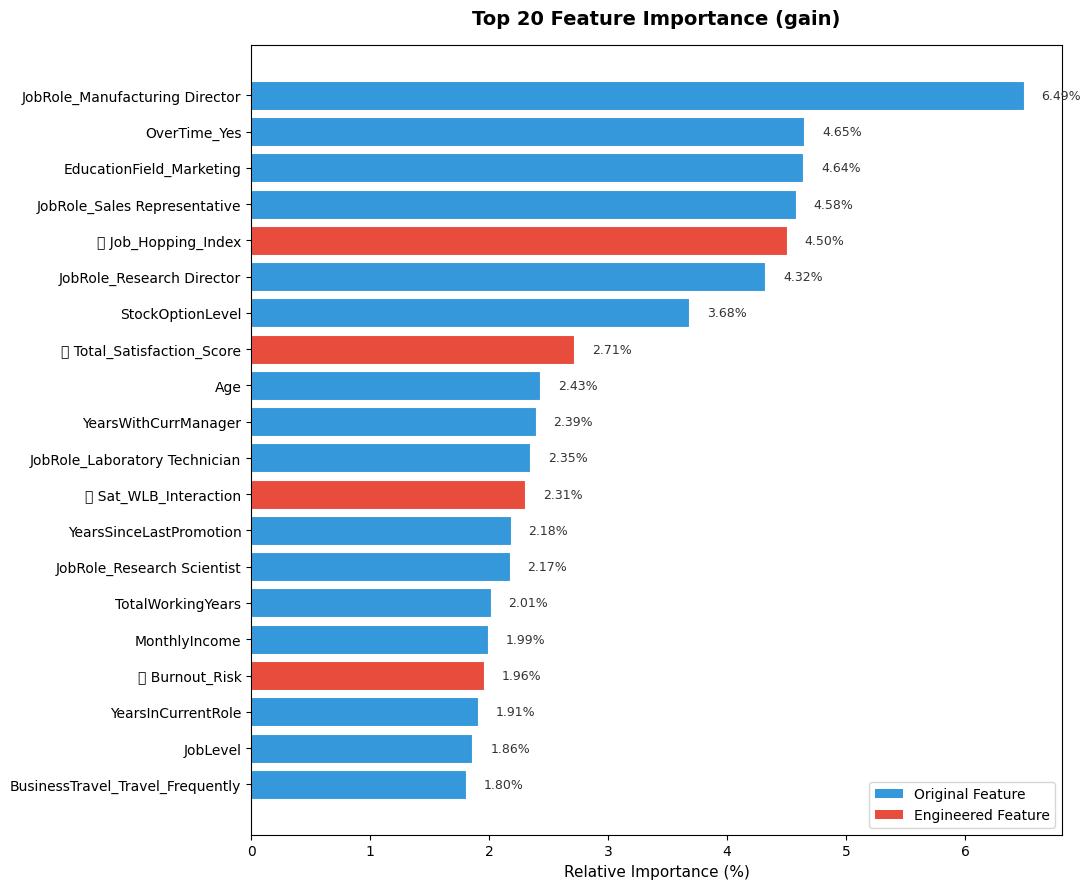

In [14]:

import matplotlib.pyplot as plt
import seaborn as sns

num_feature_names = numerical_cols_eng
cat_encoder       = preprocessor_eng.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols).tolist()

all_feature_names = np.array(num_feature_names + cat_feature_names)

assert len(all_feature_names) == X_train_eng_proc.shape[1], \
    f"이름 수({len(all_feature_names)}) ≠ 컬럼 수({X_train_eng_proc.shape[1]})"

original_cols = set(df.drop('Attrition', axis=1).columns)
engineered_features = [c for c in numerical_cols_eng if c not in original_cols]

IMPORTANCE_TYPE = 'gain'

booster = best_xgb_eng_optuna.get_booster()
booster.feature_names = all_feature_names.tolist()
score_dict = booster.get_score(importance_type=IMPORTANCE_TYPE)

imp_df = (
    pd.DataFrame({
        'feature': list(score_dict.keys()),
        'importance': list(score_dict.values())
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

# 정규화 (상대 기여도, %)
imp_df['importance_pct'] = imp_df['importance'] / imp_df['importance'].sum() * 100

# 신규 파생 변수 표시
imp_df['is_engineered'] = imp_df['feature'].isin(engineered_features)
imp_df['display_name']  = imp_df.apply(
    lambda r: f"🆕 {r['feature']}" if r['is_engineered'] else r['feature'],
    axis=1
)

top20 = imp_df.head(20).iloc[::-1]

# ---------- 4) 시각화 ----------
plt.figure(figsize=(11, 9))
colors = ['#E74C3C' if eng else '#3498DB' for eng in top20['is_engineered']]

bars = plt.barh(top20['display_name'], top20['importance_pct'],
                color=colors, edgecolor='white', linewidth=0.8)

# 막대 끝에 수치 표시
for bar, val in zip(bars, top20['importance_pct']):
    plt.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}%', va='center', fontsize=9, color='#333')

plt.title(f'Top 20 Feature Importance ({IMPORTANCE_TYPE})',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Relative Importance (%)', fontsize=11)
plt.ylabel('')

# 범례
from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor='#3498DB', label='Original Feature'),
    Patch(facecolor='#E74C3C', label='Engineered Feature')
]
plt.legend(handles=legend_elems, loc='lower right', fontsize=10, frameon=True)

plt.tight_layout()
plt.savefig('XGBoost_Feature_Importance_Top20.pdf', dpi=150, bbox_inches='tight')
plt.show()

